# 1. **基本路径操作**


In [3]:
from pathlib import Path

# 创建Path对象
p = Path('/home/user/d/tmp_task/01_SVs_stat/raw.txt')

# 获取不同部分
print(p.name)          
print(p.stem)          
print(p.suffix)        
print(p.parent)         
print(p.parts)          

raw.txt
raw
.txt
/home/user/d/tmp_task/01_SVs_stat
('/', 'home', 'user', 'd', 'tmp_task', '01_SVs_stat', 'raw.txt')


# 1. **检查文件和目录**

In [ ]:
p = Path('../data/20260327/ieu-a-2.vcf.gz')

# 检查属性
print(p.exists())      # 是否存在
print(p.is_file())     # 是否是文件
print(p.is_dir())      # 是否是目录
print(p.is_absolute()) # 是否是绝对路径

# 获取文件信息
if p.exists():
    print(p.stat().st_size)    # 文件大小
    print(p.stat().st_mtime)   # 修改时间

# 导入人类友好格式化库
import humanize
from datetime import datetime
if p.exists():
    print(humanize.naturalsize(p.stat().st_size))    # 文件大小
    print(datetime.fromtimestamp(p.stat().st_mtime))   # 修改时间

True
True
False
False
65645898
1733695949.0
65.6 MB
2024-12-09 06:12:29


# 3. **遍历目录**

In [ ]:
# 列出目录下所有.py文件
for py_file in Path('.').glob('*.py'):
    print(py_file)

# 递归查找所有Python文件
for py_file in Path('src').rglob('*.py'):
    print(py_file)

# 列出目录内容
for item in Path('.').iterdir():
    if item.is_dir():
        print(f"目录: {item}")

# 4.路径操作和创建

In [ ]:
# 创建目录（自动创建父目录）
Path('data/raw/2024').mkdir(parents=True, exist_ok=True)

# 重命名/移动文件
source = Path('old_name.txt')
source.rename('new_name.txt')

# 复制文件（需要shutil辅助）
import shutil
shutil.copy2('source.txt', Path('backup') / 'source.txt')

# 5. 实用例子：处理文件集合

In [8]:
# 批量重命名图片
for i, img_path in enumerate(Path('images').glob('*.jpg')):
    new_name = f'photo_{i:03d}.jpg'
    img_path.rename(img_path.parent / new_name)

# 查找所有包含特定文本的文件
search_text = 'TODO'
for py_file in Path('.').rglob('*.py'):
    if search_text in py_file.read_text():
        print(f"在 {py_file} 中找到 {search_text}")

# 6.与字符串的互操作

In [ ]:
p = Path('/home/user/file.txt')

# Path转字符串
str_path = str(p)  # 或直接使用 p.as_posix()

# 字符串转Path
s = '/home/user/file.txt'
p = Path(s)  # 自动转换

# 在需要字符串的API中使用
import pandas as pd
df = pd.read_csv(Path('data.csv'))  # 很多库现在支持Path对象

# 7. 与 os.path 的对比（为什么推荐 pathlib）


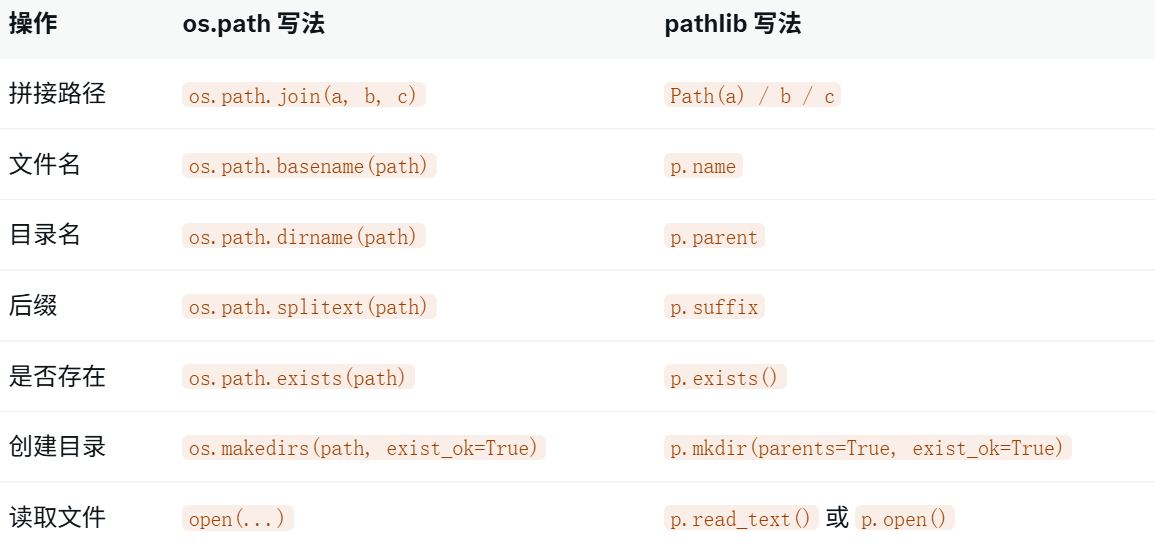